# Classification of MNIST

#### About MNIST Dataset
- Type: Images
- Img size: 28x28
- Dataset Size: 70,000
- Authors: high school students & employees of the US Census Bureau

Scikit-Learn provides `fetch_openml` helper function to download many popular datasets from OpenML.org 

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
## Desctiption of dataset
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [3]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [4]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

- So shape attribute shows that dataset has 70K records with 784 features (28x28 ratio, grayscale, 1 is black, 0 is white)   

In [5]:
X.shape, y.shape

((70000, 784), (70000,))

We can visually see the digits using `plt.imshow` from `matplotlib`

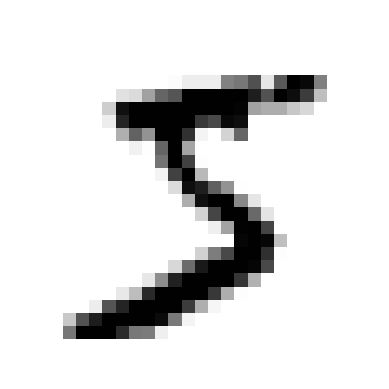

That'is  5


In [6]:
import matplotlib.pyplot as plt

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

print("That'is ", y[0])


### Dataset Split

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

- `SGDClassifier` classfier provided by scikit-learn is capable of handling very large datasets efficiently 
- We try first binary classification, so we have to remap labels into binary, that is 5 or not. 

In [45]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

## Binary Classification

In [46]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [47]:
sgd_clf.predict([some_digit])

array([ True])

Yeap, model got it right, it is true and was 5

### Measuring Performance

In [48]:
from sklearn.model_selection import cross_val_score
train_scores = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

Hmm, that pretty good accuracy, 96%. let's see accuracy in test set

In [49]:
test_scores = cross_val_score(sgd_clf, X_test, y_test_5, cv=3, scoring="accuracy")

In [50]:
print("Train accuracy:", train_scores.mean().round(4), "Test accuracy:", test_scores.mean().round(4))

Train accuracy: 0.957 Test accuracy: 0.9567


### Cross-Validation Implementation

Learn how to customize cross-validation, by implementing it from scratch

In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


### Confusion Matrix

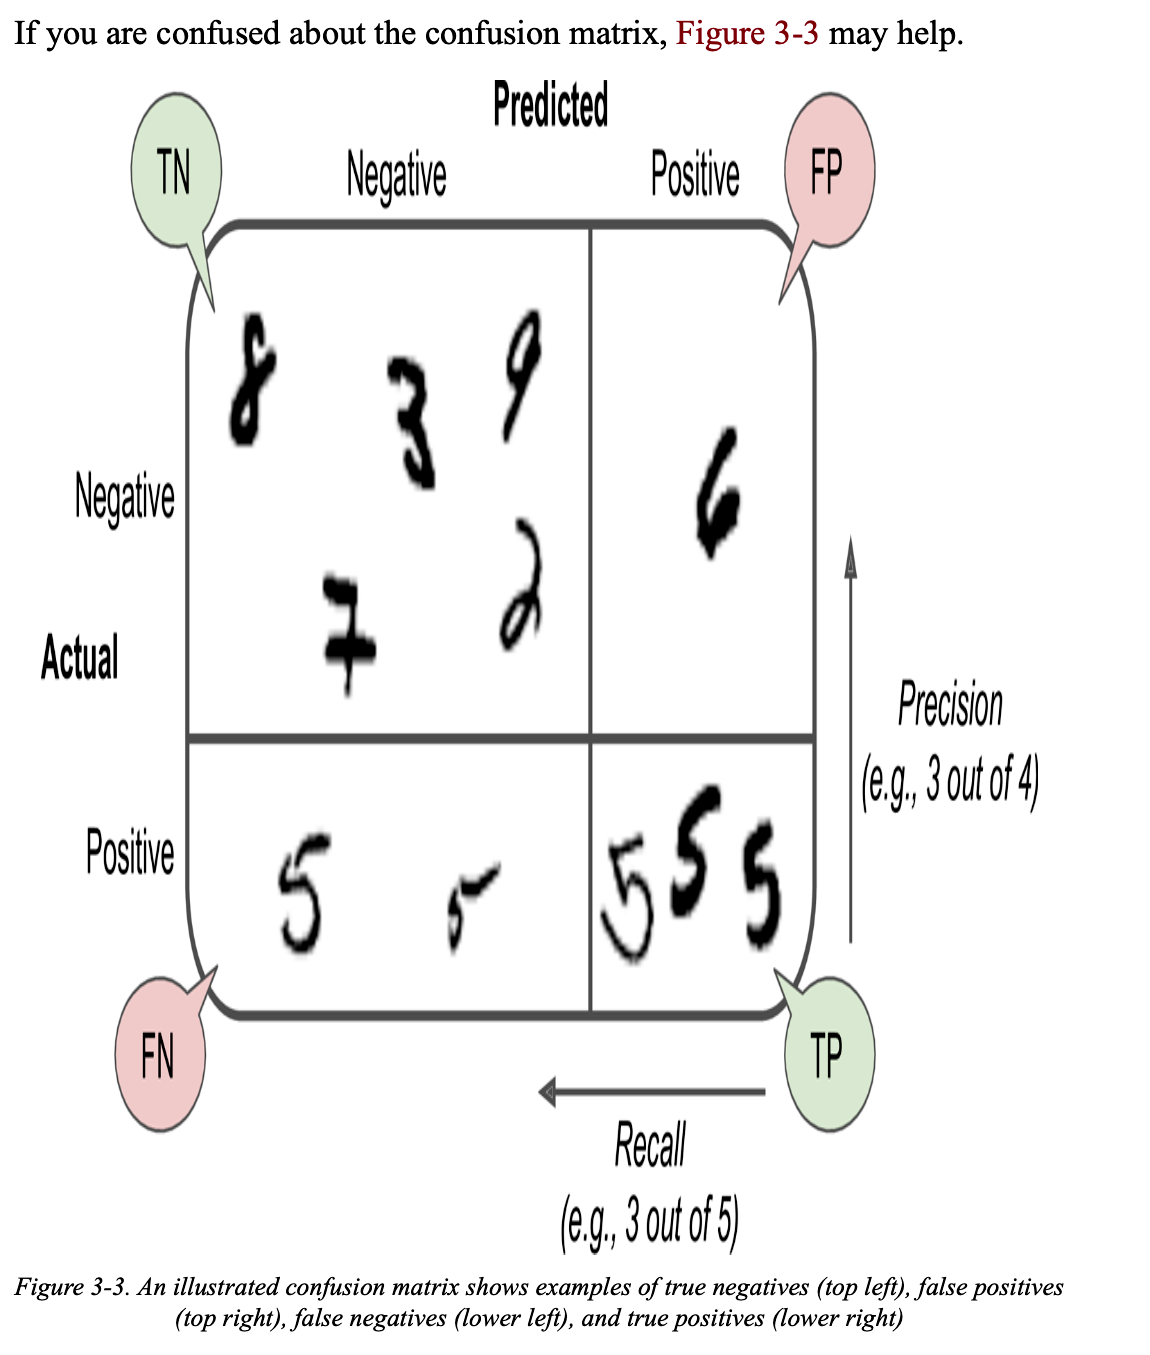

In [52]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)

In [53]:
cm

array([[53892,   687],
       [ 1891,  3530]])

### Precision & Recall

* Precision: "When the model predicts positive, how often is it correct?"
* Recall: "How many actual positives did the model find?"

In [54]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

print("Precision:", precision, "Recall:", recall)


Precision: 0.8370879772350012 Recall: 0.6511713705958311


### F1 score
A single score that balances precision and recall

In [55]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)
print("F1 Score:", f1)

F1 Score: 0.7325171197343847


In [56]:
y_scores = sgd_clf.decision_function([some_digit])
threshold = 0
y_scores > threshold

array([ True])

In [57]:
threshold = 3000
y_scores > threshold

array([False])

In [58]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
method="decision_function")

y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

With these scores, use the `precision_recall_curve()` function to compute precision and recall for all possible thresholds (the function adds a last precision of 0 and a last recall of 1, corresponding to an infinite threshold):

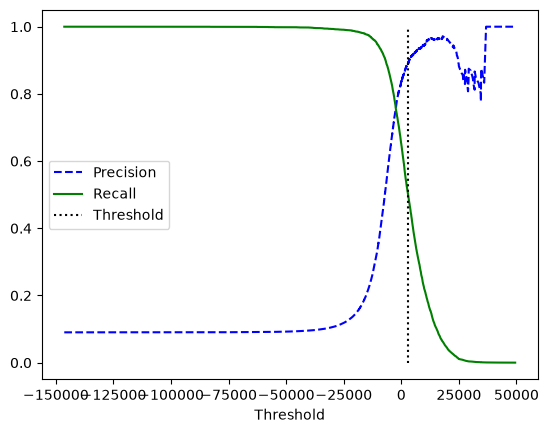

In [59]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.vlines(threshold, 0, 1.0, "k", 'dotted', label="Threshold")
plt.xlabel("Threshold")
plt.legend()
plt.show()

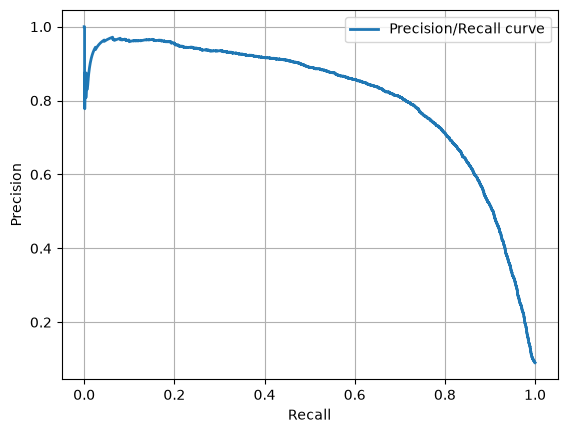

In [60]:
plt.plot(recalls, precisions, linewidth=2,
label="Precision/Recall curve")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend()
plt.show()

### Suppose we decided to aim for 90% precision

In [61]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]

In [62]:
threshold_for_90_precision

np.float64(3370.019499144183)

In [63]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
precision_score(y_train_5, y_train_pred_90)


0.9000345901072293

##### Achieved, now let's check recall when precision is 90

In [64]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

But wait, not so fast: a high-precision
classifier is not very useful if its recall is too low! For many applications,
48% recall wouldn’t be great at all.

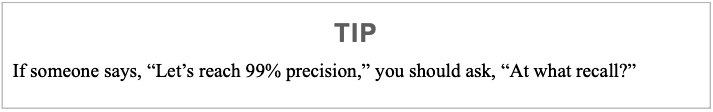

#### The ROC Curve
##### Receiver Operation Characteristics

- FPR (False Positive Rate) vs TNR (True Positive Rate)

In [65]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)   

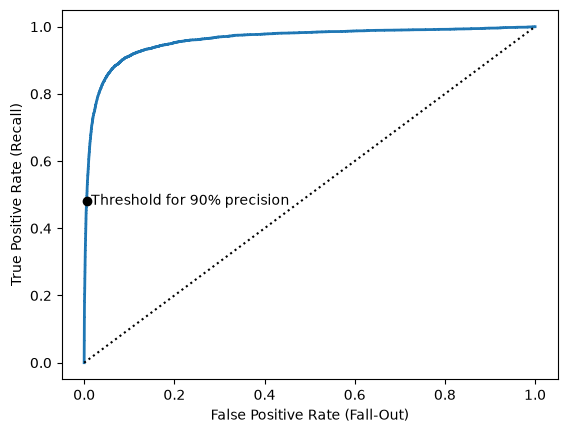

In [66]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.ylabel("True Positive Rate (Recall)")
plt.xlabel("False Positive Rate (Fall-Out)")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.text(fpr_90 + 0.01, tpr_90 - 0.01, "Threshold for 90% precision")

plt.show()


Since the ROC curve is so similar to the precision/recall (PR) curve, you may wonder
how to decide which one to use. As a rule of thumb, you should prefer the PR curve
whenever the positive class is rare or when you care more about the false positives than
the false negatives. Otherwise, use the ROC curve. For example, looking at the previous
ROC curve (and the ROC AUC score), you may think that the classifier is really good.
But this is mostly because there are few positives (5s) compared to the negatives (non-
5s). In contrast, the PR curve makes it clear that the classifier has room for
improvement: the curve could really be closer to the top-right corner

In [67]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

Let’s now create a RandomForestClassifier, and we will compare its PR curve and F1 score to those of the SGDClassifier:

In [68]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.98, 0.02]])

- This is the numpy array of estimated probablities for 1st and 2nd number images
- 1st row tells us, the image of number is 5 with 89% probablity and 2 row is not 5 with 98% probablity

In [69]:
mask = (y_probas_forest[:, 1] > 0.5) & (y_probas_forest[:, 1] < 0.6)

y_probas_forest[mask].shape

(370, 2)

In [70]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

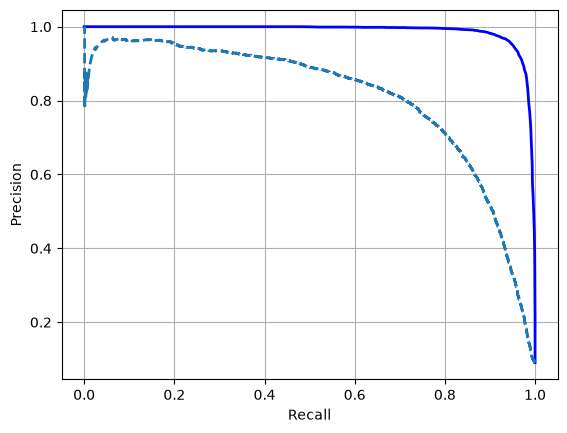

In [71]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.grid()
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [72]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5

In [74]:
f1_score(y_train_5, y_train_pred_forest)

0.9270445185330457

In [75]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983296721818179

## Multi-Class Classification

Some scikit-learn libraries:
- LogisticRegression
- RandomForestClassifier
- GuassianNB are native for multi-class classification

Two classification strategies: 

- OvR - One versus Rest. 
- OvO - One versus One. N x (N-1) / 2 Classifiers are trained. (N - number of classes)

In [76]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


Support Vector Classifer performs poorly with large train data so we sliced 2000 of training set 

In [ ]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

- SVC chose for OvO strategy, so it  results 10 scores for each class
- Those scores are accessible using `deision_function` method

In [84]:
some_digit_scores = svm_clf.decision_function([some_digit])

`argmax` returns the index of biggest number from the array

In [88]:
class_id =some_digit_scores.argmax()

The list of classes is accessible using `classes_` attribute

In [89]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [90]:
svm_clf.classes_[class_id]

'5'

if we wanna force model to use OvO or OvR, wrapping the model class when initialization with `OneVsRestClassifier` or `OneVsOneClassifier` is enough

In [25]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

ovr_clf = OneVsRestClassifier(SVC(random_state=42, probability=True))
ovr_clf.fit(X_train[:2000], y_train[:2000])

/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(probabili...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[<U1](10,)","['0','1','2',...,'7','8','9']"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[SVC(probabili...ndom_state=42), SVC(probabili...ndom_state=42), SVC(probabili...ndom_state=42), SVC(probabili...ndom_state=42), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,784
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True


In [26]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [27]:
len(ovr_clf.estimators_)

10

- Our `SVC` model wrapped `OneVsRestClassifier` predicted the digit correct, and now as we can see the number of estimators is 10 not 45. (In case of OvO, the number of estimators would be 45, since Nx(N-1)/2 = 10*(10-1)/2 = 10*9/2 = 90/2= 45)

- Let's calculate metrics to see the actual score

In [28]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score


predictions = ovr_clf.predict(X_test)

acc = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')

print("Accuracy:", acc, "Precision:", precision, "Recall:", recall, "F1 Score:", f1)

Accuracy: 0.9256 Precision: 0.9250867341699859 Recall: 0.9247431032030183 F1 Score: 0.9245943760224827


Well, here explanation for all metrics:
- Accuracy (0.9256): The proportion of all predictions that were correct. An accuracy of 92.56% means the model correctly classified about 93 out of every 100 samples.
- Precision (0.9251): Of all samples the model predicted as a given class, 92.51% were actually from that class. Higher precision means fewer false positives.
- Recall (0.9247): Of all samples that truly belonged to a class, the model correctly identified 92.47% of them. Higher recall means fewer false negatives.
- F1 Score (0.9246): The harmonic mean of precision and recall. It provides a single measure that balances both types of errors, with 92.46% indicating strong overall classification performance.

In [ ]:
y_scores = ovr_clf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_scores, average='macro', multi_class='ovr' )

`probability=True` must be set when creating the SVC classifier. The `predict_proba` method returns the probability estimates for each class, which can be used to compute the ROC AUC score.

In [31]:
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9939706338466034


 - ROC AUC Score (0.9940): Measures the model's ability to distinguish between classes across all possible classification thresholds. A score of 0.994 indicates excellent discriminative performance, meaning the model can almost perfectly separate samples from different classes. A value of 1.0 represents perfect classification, while 0.5 is equivalent to random guessing.

### SGDClassifier for 10-class handwritten digit classification

In [8]:
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)

In [ ]:


sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

Hmm, predicted wrong!!

In [33]:
sgd_clf.decision_function([some_digit])

array([[-31893.03095419, -19047.55566534,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

- Only class_id 3, gives positive score while the scores for other classes are far behind and negative from the score of predicted class.
- This means our model is not very confided about predictions
- Lets do cross validation to evaluate the model

In [34]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87745, 0.85835, 0.8698 ])

Let's try scaling to increase the accuracy

In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train.astype(np.float64))

By simply applying scaling, we have improved the accuracy of our model to over 89%

In [12]:
cross_val_score(sgd_clf, X_scaled, y_train, cv=3, scoring="accuracy")

KeyboardInterrupt: 

/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


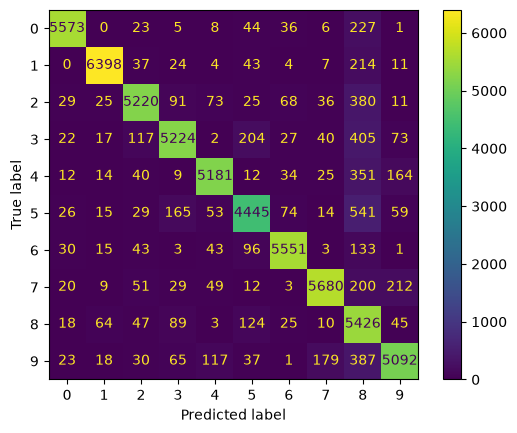

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(sgd_clf, X_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

- Above confusion matrix shows how many errors/confusions were made between the pair of true and predicted classes
- Most confusions/mispredictions/FPs is happening with 8

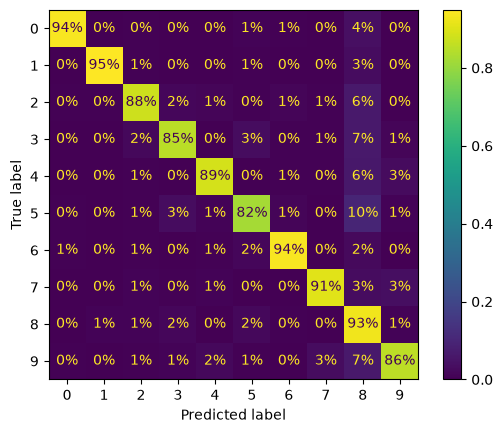

In [11]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")
plt.show()

- Above confusion matrix shows the how much percent of total GTs/true labels (y axis) were mispredicted (x axis) 
- The sum of percentages in rows are equal to 100%, this makes up total number of <b>instances</b> of the class in that row

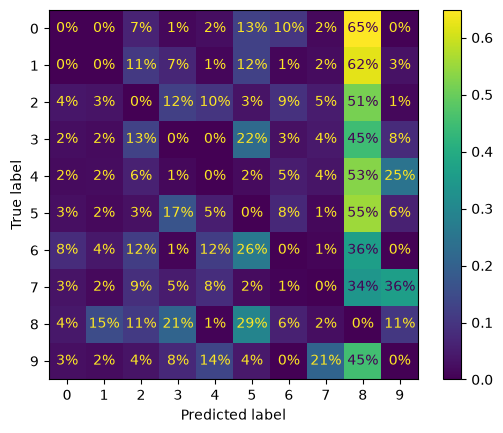

In [15]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", sample_weight=(y_train_pred != y_train), values_format=".0%")
plt.show()


- Above confusion matrix shows the how much percentage of errors/mispredictions of particular class were made on which class 
- The sum of percentages in rows are equal to 100%, this makes up total number of <b>errors</b> of the class in that row

### Conclusion of Error Analysis

Thus, most errors happening with 8, so we have to improve our model using different methods:
- Collecting more data of 8s 
- Applying algorithm to count the number of closed loops 
- Preprocess digit images (augmentation methods, e.g.scikit-image,pillow,opencv)